<a href="https://colab.research.google.com/github/DerekGossani/DerekGossani/blob/main/F%C3%A1brica_Sustent%C3%A1vel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introdução**

Uma fábrica deseja otimizar seu consumo de energia elétrica com base na produção diária.
Para isso, será criado um protótipo de sistema especialista de apoio à decisão que:

- Analisa dados históricos de produção e consumo;

- Visualiza padrões com gráficos;

- Classifica dias de alto ou baixo consumo;

- Cria um modelo preditivo de consumo energético.

# **Etapa 1**
Nesta etapa, importamos as bibliotecas necessárias para manipular, visualizar e modelar os dados.
Cada uma tem uma função importante:

- Pandas e NumPy: análise e cálculo;

- Matplotlib e Seaborn: gráficos;

- Scikit-learn: classificação;

- TensorFlow: rede neural para predição.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# **Etapa 2**

Agora, vamos carregar o arquivo fabrica_energia.csv que contém os dados da produção e consumo da fábrica.
Depois mostramos as primeiras linhas para verificar se foi lido corretamente.

In [3]:
df = pd.read_csv("fabrica_energia.csv")
print(df.head())


   dia  horas_trabalhadas  unidades_produzidas  consumo_kwh maquina
0    1                  6                   58          260       A
1    2                  7                   65          300       B
2    3                  8                   72          310       A
3    4                  9                   85          330       B
4    5                  5                   45          210       A


# **Etapa 3**

Aqui vamos:

- Calcular estatísticas básicas;

- Descobrir o consumo médio, desvio padrão e total por máquina;

- Identificar o dia com maior e menor produção.

- Essas análises ajudam a entender como a produção influencia o consumo.

In [4]:
# Estatísticas básicas
print(df.describe())

# Média, desvio padrão e total de consumo por máquina
resumo_maquinas = df.groupby('maquina')['consumo_kwh'].agg(['mean', 'std', 'sum'])
print(resumo_maquinas)

# Dia com maior e menor produção
maior = df.loc[df['unidades_produzidas'].idxmax()]
menor = df.loc[df['unidades_produzidas'].idxmin()]

print("Dia com maior produção:\n", maior)
print("Dia com menor produção:\n", menor)


            dia  horas_trabalhadas  unidades_produzidas  consumo_kwh
count  10.00000          10.000000            10.000000    10.000000
mean    5.50000           7.500000            69.800000   299.500000
std     3.02765           1.581139            14.913082    43.744841
min     1.00000           5.000000            45.000000   210.000000
25%     3.25000           6.250000            59.750000   276.250000
50%     5.50000           7.500000            70.000000   305.000000
75%     7.75000           8.750000            78.750000   327.500000
max    10.00000          10.000000            95.000000   360.000000
          mean        std   sum
maquina                        
A        269.0  38.470768  1345
B        330.0  22.360680  1650
Dia com maior produção:
 dia                      6
horas_trabalhadas       10
unidades_produzidas     95
consumo_kwh            360
maquina                  B
Name: 5, dtype: object
Dia com menor produção:
 dia                      5
horas_trabalhada

# **Etapa 4**

Nesta parte, vamos enxergar padrões através de gráficos:

- O primeiro mostra a relação entre horas trabalhadas e consumo energético;

- O segundo mostra como o consumo variou ao longo dos dias.

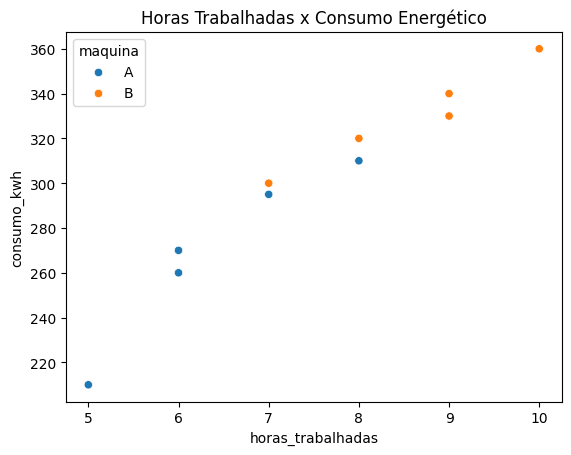

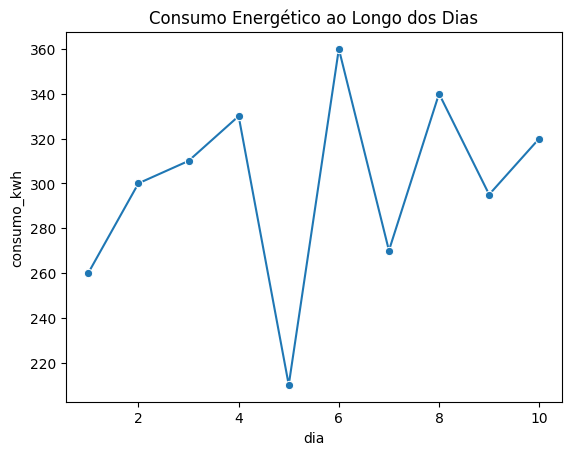

In [5]:
# Gráfico de dispersão: horas trabalhadas × consumo energético
sns.scatterplot(data=df, x='horas_trabalhadas', y='consumo_kwh', hue='maquina')
plt.title("Horas Trabalhadas x Consumo Energético")
plt.show()

# Gráfico de linha: consumo energético ao longo dos dias
sns.lineplot(data=df, x='dia', y='consumo_kwh', marker='o')
plt.title("Consumo Energético ao Longo dos Dias")
plt.show()


# **Etapa 5**

Agora vamos criar uma nova coluna chamada alto_consumo, que será 1 se o consumo for acima da média, e 0 caso contrário.

Em seguida, treinaremos um modelo de Árvore de Decisão para tentar prever se um novo dia será de alto consumo, com base nas horas e unidades produzidas.

In [6]:
media_consumo = df['consumo_kwh'].mean()
df['alto_consumo'] = (df['consumo_kwh'] > media_consumo).astype(int)
print(df.head())

X = df[['horas_trabalhadas', 'unidades_produzidas']]
y = df['alto_consumo']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


   dia  horas_trabalhadas  unidades_produzidas  consumo_kwh maquina  \
0    1                  6                   58          260       A   
1    2                  7                   65          300       B   
2    3                  8                   72          310       A   
3    4                  9                   85          330       B   
4    5                  5                   45          210       A   

   alto_consumo  
0             0  
1             1  
2             1  
3             1  
4             0  
Acurácia: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



# **Etapa 6**

Por fim, vamos criar uma rede neural simples para prever o valor do consumo_kwh.
A rede aprende padrões não lineares e tenta prever o consumo real com base nas variáveis de produção.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


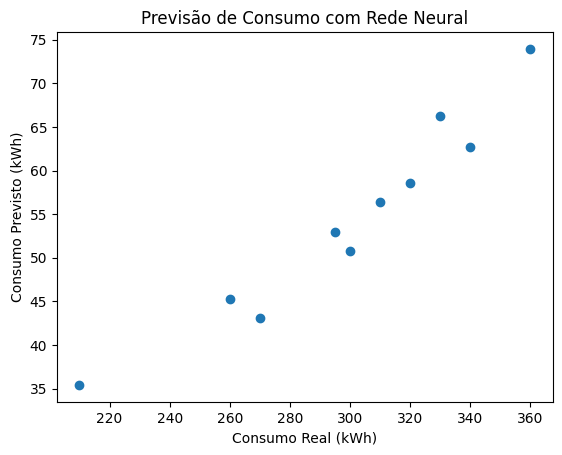

In [7]:
# Normaliza os dados (melhora o treino)
X = df[['horas_trabalhadas', 'unidades_produzidas']].values
y = df['consumo_kwh'].values

modelo_nn = Sequential([
    Dense(8, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1)
])

modelo_nn.compile(optimizer='adam', loss='mse')
modelo_nn.fit(X, y, epochs=100, verbose=0)

# Fazer predição
pred = modelo_nn.predict(X)
plt.scatter(y, pred)
plt.xlabel("Consumo Real (kWh)")
plt.ylabel("Consumo Previsto (kWh)")
plt.title("Previsão de Consumo com Rede Neural")
plt.show()


# **Conclusão**

Com base neste estudo, conseguimos identificar de forma mais clara como a produção impacta diretamente o consumo de energia da fábrica. A partir das análises e previsões realizadas, é possível tomar decisões mais estratégicas sobre o uso de máquinas e horários de trabalho, buscando sempre o equilíbrio entre produtividade e economia de energia. Essa visão permite à empresa reduzir custos operacionais e reforçar seu compromisso com a sustentabilidade e a eficiência no processo produtivo.